He encontrado 1019 imágenes válidas.
Imagen: CarLongPlateGen2458_jpg.rf.64e073a5762e853b172738eb7659243a.jpg -> Texto: F16159 (FORMATO INCORRECTO)


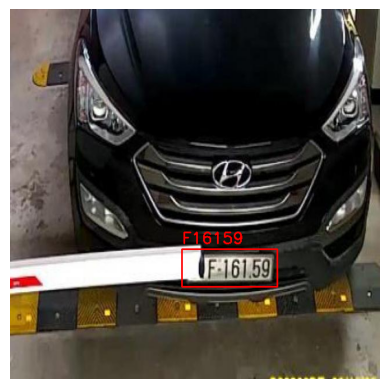

Imagen: xemay1470_jpg.rf.9292dd0b8e0284a6b74ef0661f8774b8.jpg -> Texto: 5252 (FORMATO INCORRECTO)


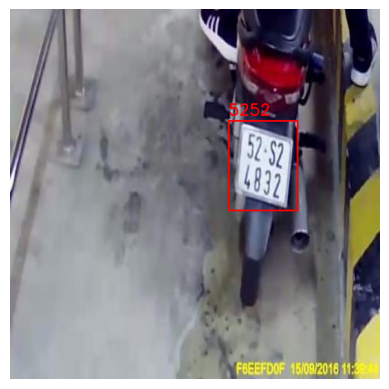

Imagen: pic_125_jpg.rf.bb69623949b2a19c25bc6664f0d2ddb9.jpg -> Texto: 16T814 (FORMATO INCORRECTO)


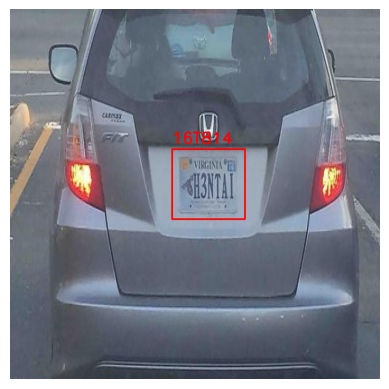

Imagen: 1649292507325_jpg.rf.1dd862911958ea73a2c97fcb6b60da2c.jpg -> Texto: U (FORMATO INCORRECTO)


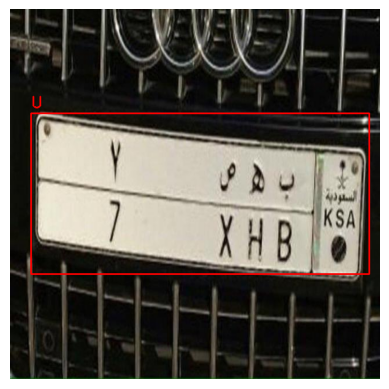

Imagen: pic_391_jpg.rf.5b42825b95a9160730f926396f53ce74.jpg -> Texto: EPIBB (FORMATO INCORRECTO)


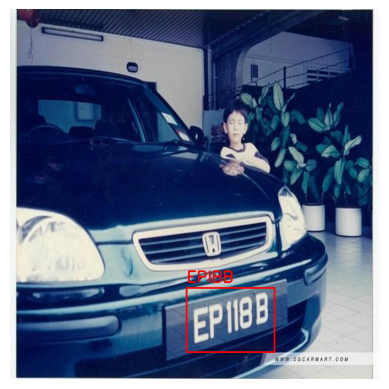

In [21]:
import cv2
import os
import easyocr
import re
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. CONFIGURACIÓN INICIAL
# Cargamos el modelo YOLO entrenado para localizar matrículas
model = YOLO('license-plate-finetune-v1l.pt') 
# Inicializamos el lector de EasyOCR para el idioma español
reader = easyocr.Reader(['es']) 
# Definimos la ruta de la carpeta de imágenes (ajustada a la estructura de Roboflow)
folder_path = 'dataset/test/images' 

# Filtramos los archivos para trabajar solo con formatos de imagen válidos
files = [f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
print(f"He encontrado {len(files)} imágenes válidas.")

# 2. BUCLE DE PROCESAMIENTO
# Recorremos las imágenes (limitado a las 5 primeras para los entregables)
for filename in files[:5]: 
    img_path = os.path.join(folder_path, filename)
    img = cv2.imread(img_path) # Leemos la imagen con OpenCV
    if img is None: continue

    # FASE 1: DETECCIÓN
    # El modelo busca matrículas en la imagen (verbose=False oculta logs innecesarios)
    results = model(img, verbose=False) 

    for result in results:
        for box in result.boxes:
            # Obtenemos la confianza de la detección (qué tan segura está la IA)
            conf = box.conf[0].item()
            
            # Filtramos para usar solo detecciones con más del 50% de confianza
            if conf > 0.5: 
                # Obtenemos las coordenadas de la caja delimitadora (x1, y1, x2, y2)
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                
                # FASE 2: RECORTE Y PREPROCESAMIENTO
                # Recortamos solo la zona de la matrícula para facilitar el OCR
                plate_crop = img[y1:y2, x1:x2]
                # Pasamos el recorte a escala de grises para eliminar ruido de color
                gray = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2GRAY)
                # Aplicamos umbralado de Otsu para obtener blanco y negro puro (binarización)
                thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

                # FASE 3: LECTURA OCR Y VALIDACIÓN
                # El OCR lee el texto del recorte binarizado
                ocr_result = reader.readtext(thresh)
                if ocr_result:
                    raw_text = ocr_result[0][1] # Extraemos el texto detectado
                    # Limpiamos el texto: solo letras/números y todo a mayúsculas
                    clean_text = "".join(e for e in raw_text if e.isalnum()).upper()
                    
                    # Validación mediante expresiones regulares: 4 números seguidos de 3 letras
                    es_valida = bool(re.match(r'^\d{4}[A-Z]{3}$', clean_text))
                    status = "VALIDA" if es_valida else "FORMATO INCORRECTO"
                    
                    print(f"Imagen: {filename} -> Texto: {clean_text} ({status})")

                    # FASE 4: VISUALIZACIÓN Y GUARDADO
                    # Elegimos color: Verde si cumple el formato español, Rojo si no
                    color = (0, 255, 0) if es_valida else (0, 0, 255)
                    # Dibujamos el rectángulo alrededor de la matrícula detectada
                    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                    # Escribimos el texto reconocido sobre la imagen
                    cv2.putText(img, clean_text, (x1, y1 - 10), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)
                    
                    # Guardamos la imagen resultante para la entrega
                    cv2.imwrite(f'resultado_{filename}', img)
                    # Mostramos el resultado final en el Notebook usando Matplotlib
                    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                    plt.axis('off')
                    plt.show()

¿Qué pasa si la matrícula está inclinada o hay poca luz?

Informe Comparativo de Resultados
1. Factores que afectan al rendimiento

    Inclinación: La perspectiva (como en la foto del Hyundai) deforma los caracteres, haciendo que el OCR confunda letras o números similares (ej. un . por un 1).

    Poca Luz y Sombras: La falta de iluminación reduce el contraste. Aunque el umbralado (thresholding) ayuda, el ruido visual dificulta que EasyOCR reconozca el texto correctamente.

    Obstáculos: Elementos como barreras de parking que tapan parte de la placa impiden la lectura completa, aunque la detección de la caja (YOLO) sea exitosa.

2. Conclusión del Formato

    El sistema está diseñado para el formato español (4 números y 3 letras). El mensaje "FORMATO INCORRECTO" en los resultados de Roboflow es normal, ya que el dataset contiene placas internacionales que no siguen este patrón.